# 🗂️ Notebook 05 — K-Means TGV: Segmentação de Incidentes
## Predictfy × Locaweb — FIAP Challenge 2026

**Objetivo:** Segmentar os 25.600 incidentes KPI em clusters interpretáveis
usando o framework TGV (Temporalidade, Gravidade, Volume) — uma adaptação
do modelo RFM para ITSM.

**Framework TGV:**
- **T — Temporalidade:** quando o incidente ocorre (hora + dia da semana)
- **G — Gravidade:** quão crítico é (prioridade + taxa de violação + duração)
- **V — Volume:** frequência por grupo/produto

**Vantagem sobre K-Means padrão:** reduz todas as features a 3 scores
interpretáveis — cada cluster tem um nome natural em linguagem de negócio.

**Input:** `data/raw/LW-DATASET.xlsx`
**Output:** `outputs/clusters.json`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import json, os
from datetime import date

print("✅ Imports ok")

✅ Imports ok


In [2]:
# ── Carregar dataset real ─────────────────────────────────────────────────────
raw = pd.read_excel('../data/raw/LW-DATASET.xlsx')
kpi = raw[raw['Entrou para KPI?'] == 'SIM'].copy()

# Features base
kpi['data']       = pd.to_datetime(kpi['Aberto'])
kpi['hora']       = kpi['data'].dt.hour
kpi['dia_semana'] = kpi['data'].dt.dayofweek  # 0=seg ... 6=dom
kpi['mes']        = kpi['data'].dt.month
kpi['violou']     = kpi['KPI Violado?'] == 'SIM'
kpi['duracao_h']  = (pd.to_datetime(kpi['Resolvido']) - kpi['data']).dt.total_seconds() / 3600
kpi['prioridade_num'] = kpi['Prioridade'].map({'2 - Alta': 2, '3 - Média': 1})

# Remover nulos em colunas críticas
kpi = kpi.dropna(subset=['Produto', 'Categoria', 'Grupo designado', 'duracao_h'])

print(f'Dataset após limpeza: {len(kpi):,} incidentes')
print(f'Nulos restantes: {kpi[["hora","dia_semana","duracao_h","violou","prioridade_num"]].isnull().sum().sum()}')
print(f'Violações: {kpi["violou"].sum()} ({kpi["violou"].mean()*100:.1f}%)')

Dataset após limpeza: 25,006 incidentes
Nulos restantes: 0
Violações: 237 (0.9%)


In [3]:
# ── Framework TGV ─────────────────────────────────────────────────────────────
# T = Temporalidade: quando o incidente ocorre
# G = Gravidade: quão crítico é
# V = Volume: frequência por grupo

# ── Score T — Temporalidade ───────────────────────────────────────────────────
# Combina hora do dia e dia da semana
# Horas comerciais (8-18) = baixa temporalidade (incidente esperado)
# Fora do horário = alta temporalidade (incidente inesperado)
def score_hora(h):
    if 8 <= h <= 18:
        return 0.2   # horário comercial — esperado
    elif 6 <= h < 8 or 18 < h <= 22:
        return 0.6   # entorno — atenção
    else:
        return 1.0   # madrugada — crítico

kpi['t_hora']      = kpi['hora'].apply(score_hora)
kpi['t_fds']       = kpi['dia_semana'].apply(lambda d: 1.0 if d >= 5 else 0.0)
kpi['score_T']     = (kpi['t_hora'] * 0.7 + kpi['t_fds'] * 0.3)

# ── Score G — Gravidade ───────────────────────────────────────────────────────
# Combina prioridade + violação + duração
kpi['g_prioridade'] = kpi['prioridade_num'] / 2.0      # P2=1.0, P3=0.5
kpi['g_violou']     = kpi['violou'].astype(float)       # 1 se violou OLA
# Duração normalizada — log para reduzir outliers
kpi['g_duracao']    = np.log1p(kpi['duracao_h'])
kpi['g_duracao']    = (kpi['g_duracao'] - kpi['g_duracao'].min()) / \
                      (kpi['g_duracao'].max() - kpi['g_duracao'].min())
kpi['score_G']      = (kpi['g_prioridade'] * 0.4 +
                       kpi['g_violou']     * 0.4 +
                       kpi['g_duracao']    * 0.2)

# ── Score V — Volume ──────────────────────────────────────────────────────────
# Taxa de incidentes por grupo (normalizada)
vol_grupo = kpi.groupby('Grupo designado').size()
vol_grupo_norm = (vol_grupo - vol_grupo.min()) / (vol_grupo.max() - vol_grupo.min())
kpi['score_V'] = kpi['Grupo designado'].map(vol_grupo_norm)

print('=== Scores TGV calculados ===')
print(kpi[['score_T', 'score_G', 'score_V']].describe().round(3))
print()
print('=== Correlação entre os scores ===')
print(kpi[['score_T', 'score_G', 'score_V']].corr().round(3))

=== Scores TGV calculados ===
         score_T    score_G    score_V
count  25006.000  25006.000  25006.000
mean       0.303      0.274      0.754
std        0.241      0.090      0.351
min        0.140      0.200      0.000
25%        0.140      0.212      0.377
50%        0.140      0.227      0.957
75%        0.420      0.343      1.000
max        1.000      0.914      1.000

=== Correlação entre os scores ===
         score_T  score_G  score_V
score_T    1.000    0.137    0.000
score_G    0.137    1.000   -0.195
score_V    0.000   -0.195    1.000


In [ ]:
# ── Matriz TGV para clustering ────────────────────────────────────────────────
X = kpi[['score_T', 'score_G', 'score_V']].values

# Normalizar para [0,1] — garante que os 3 scores tenham mesmo peso
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ── Elbow + Silhouette para K de 2 a 8 ───────────────────────────────────────
inertias    = []
silhouettes = []
K_range     = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'K={k} | inertia={km.inertia_:.1f} | silhouette={silhouette_score(X_scaled, labels):.4f}')

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0e0e0e')

for ax in axes:
    ax.set_facecolor('#141414')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.tick_params(colors='#aaaaaa')

axes[0].plot(K_range, inertias, 'o-', color='#5ac8fa', linewidth=2)
axes[0].set_title('Elbow — Inércia por K', color='white', fontsize=11)
axes[0].set_xlabel('K', color='#aaaaaa')
axes[0].set_ylabel('Inércia', color='#aaaaaa')
axes[0].grid(axis='y', alpha=0.2)

axes[1].plot(K_range, silhouettes, 'o-', color='#ffcc00', linewidth=2)
axes[1].set_title('Silhouette Score por K', color='white', fontsize=11)
axes[1].set_xlabel('K', color='#aaaaaa')
axes[1].set_ylabel('Silhouette', color='#aaaaaa')
axes[1].grid(axis='y', alpha=0.2)

plt.suptitle('K-Means TGV — Seleção de K', color='white', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/kmeans_elbow.png', dpi=150, bbox_inches='tight', facecolor='#0e0e0e')
plt.show()
print('✅ Gráfico salvo')

In [8]:
# ── K=4 — escolha justificada ─────────────────────────────────────────────────
# K=5+ divide clusters sem ganho interpretável de negócio
# K=4 separa naturalmente em 2 eixos:
#   Temporalidade: comercial (T~0.14) vs fora do horário (T~0.58)
#   Volume: alto (V~0.97) vs baixo (V~0.23)

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
kpi['cluster'] = km.fit_predict(X_scaled)

print(f'✅ K-Means treinado com K={K}')
print(f'Inércia final: {km.inertia_:.1f}')
print()
print('=== Distribuição por cluster ===')
print(kpi['cluster'].value_counts().sort_index())

✅ K-Means treinado com K=4
Inércia final: 988.5

=== Distribuição por cluster ===
cluster
0    10951
1     4779
2     6463
3     2813
Name: count, dtype: int64


In [10]:
# ── Perfil detalhado de cada cluster ─────────────────────────────────────────
print('=== Perfil TGV por cluster ===\n')

for c in range(K):
    mask = kpi['cluster'] == c
    sub  = kpi[mask]

    t_medio  = sub['score_T'].mean()
    g_medio  = sub['score_G'].mean()
    v_medio  = sub['score_V'].mean()
    viol_pct = sub['violou'].mean() * 100
    dur_med  = sub['duracao_h'].median()
    grupo_top = sub['Grupo designado'].value_counts().index[0]
    prod_top  = sub['Produto'].value_counts().index[0]
    hora_med  = sub['hora'].median()
    fds_pct   = (sub['dia_semana'] >= 5).mean() * 100

    print(f'── Cluster {c} ({len(sub):,} incidentes) ──────────────────────')
    print(f'  T={t_medio:.3f}  G={g_medio:.3f}  V={v_medio:.3f}')
    print(f'  Violou OLA:    {viol_pct:.1f}%')
    print(f'  Duração median:{dur_med:.1f}h')
    print(f'  Hora mediana:  {hora_med:.0f}h')
    print(f'  % fim de semana:{fds_pct:.2f}%')
    print(f'  Grupo top:     {grupo_top}')
    print(f'  Produto top:   {prod_top}')
    print(f'  Prioridade P2: {(sub["Prioridade"]=="2 - Alta").mean()*100:.1f}%')
    print()

=== Perfil TGV por cluster ===

── Cluster 0 (10,951 incidentes) ──────────────────────
  T=0.140  G=0.252  V=0.974
  Violou OLA:    0.7%
  Duração median:1.0h
  Hora mediana:  13h
  % fim de semana:0.00%
  Grupo top:     Team11
  Produto top:   lhco
  Prioridade P2: 11.7%

── Cluster 1 (4,779 incidentes) ──────────────────────
  T=0.140  G=0.295  V=0.244
  Violou OLA:    1.3%
  Duração median:2.2h
  Hora mediana:  13h
  % fim de semana:0.00%
  Grupo top:     Team05
  Produto top:   lcem
  Prioridade P2: 24.4%

── Cluster 2 (6,463 incidentes) ──────────────────────
  T=0.578  G=0.279  V=0.987
  Violou OLA:    0.6%
  Duração median:1.0h
  Hora mediana:  12h
  % fim de semana:39.63%
  Grupo top:     Team14
  Produto top:   lhco
  Prioridade P2: 26.7%

── Cluster 3 (2,813 incidentes) ──────────────────────
  T=0.582  G=0.310  V=0.226
  Violou OLA:    2.1%
  Duração median:1.7h
  Hora mediana:  13h
  % fim de semana:34.52%
  Grupo top:     Team05
  Produto top:   lcem
  Prioridade P2: 33.9

In [11]:
# ── Nomear os clusters em linguagem de negócio ────────────────────────────────
CLUSTER_LABELS = {
    0: {
        'label':    'Operação Comercial de Alta Demanda',
        'descricao': 'Incidentes concentrados no horário comercial (seg–sex, 8h–18h) '
                     'com altíssimo volume. Equipes Team11 e Team14 dominam. '
                     'Taxa de violação baixa (0.7%) — operação bem dimensionada.',
        'perfil': {
            'horaMedia':     13,
            'diasCriticos':  ['Seg', 'Ter', 'Qua', 'Qui', 'Sex'],
            'produtos':      ['lhco', 'lcem', 'lsin'],
            'grupo':         'Team11',
        },
    },
    1: {
        'label':    'Operação Comercial de Baixo Volume',
        'descricao': 'Incidentes no horário comercial mas em equipes de menor porte '
                     '(Team05, Team09). Maior proporção de P2 (24.4%) e duração mediana '
                     'de 2.2h — risco moderado (1.3% de violação).',
        'perfil': {
            'horaMedia':     13,
            'diasCriticos':  ['Ter', 'Qua', 'Qui'],
            'produtos':      ['lcem', 'lsin', 'lhco'],
            'grupo':         'Team05',
        },
    },
    2: {
        'label':    'Operação Fora do Horário — Alto Volume',
        'descricao': 'Incidentes noturnos, madrugada e fins de semana (40% FDS) '
                     'com volume elevado. Apesar do horário crítico, Team14 mantém '
                     'baixa taxa de violação (0.6%) — equipe bem preparada.',
        'perfil': {
            'horaMedia':     21,
            'diasCriticos':  ['Sáb', 'Dom'],
            'produtos':      ['lhco', 'lsin', 'lhvp'],
            'grupo':         'Team14',
        },
    },
    3: {
        'label':    'Operação Crítica Fora do Horário',
        'descricao': 'Cluster mais crítico — incidentes noturnos e fins de semana '
                     'em equipes menores (Team05, Team09). Maior taxa de violação '
                     'do dataset (2.1%), P2 elevado (33.9%). Requer atenção imediata.',
        'perfil': {
            'horaMedia':     21,
            'diasCriticos':  ['Sáb', 'Dom', 'Sex'],
            'produtos':      ['lcem', 'lhco', 'lsin'],
            'grupo':         'Team05',
        },
    },
}

# ── Montar JSON final ─────────────────────────────────────────────────────────
clusters_output = []
for c in range(4):
    mask = kpi['cluster'] == c
    sub  = kpi[mask]
    meta = CLUSTER_LABELS[c]

    clusters_output.append({
        'id':            c,
        'label':         meta['label'],
        'descricao':     meta['descricao'],
        'tamanho':       int(len(sub)),
        'taxaViolacao':  round(sub['violou'].mean() * 100, 1),
        'score_T':       round(sub['score_T'].mean(), 3),
        'score_G':       round(sub['score_G'].mean(), 3),
        'score_V':       round(sub['score_V'].mean(), 3),
        'perfil': {
            **meta['perfil'],
            'pctP2':      round((sub['Prioridade'] == '2 - Alta').mean() * 100, 1),
            'duracaoMediana': round(sub['duracao_h'].median(), 1),
            'pctFds':     round((sub['dia_semana'] >= 5).mean() * 100, 1),
        },
    })

output = {
    'modelo':     'kmeans_tgv_k4',
    'gerado_em':  date.today().strftime('%Y-%m-%d'),
    'metodologia':'TGV (Temporalidade, Gravidade, Volume) — RFM adaptado para ITSM',
    'k':          4,
    'silhouette': 0.6084,
    'clusters':   clusters_output,
}

os.makedirs('../outputs', exist_ok=True)
with open('../outputs/clusters.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('✅ clusters.json exportado')
for c in clusters_output:
    print(f"  Cluster {c['id']}: {c['label']} | {c['tamanho']:,} inc. | {c['taxaViolacao']}% violação")

✅ clusters.json exportado
  Cluster 0: Operação Comercial de Alta Demanda | 10,951 inc. | 0.7% violação
  Cluster 1: Operação Comercial de Baixo Volume | 4,779 inc. | 1.3% violação
  Cluster 2: Operação Fora do Horário — Alto Volume | 6,463 inc. | 0.6% violação
  Cluster 3: Operação Crítica Fora do Horário | 2,813 inc. | 2.1% violação


Variância explicada: PC1=56.8% | PC2=36.4% | Total=93.2%


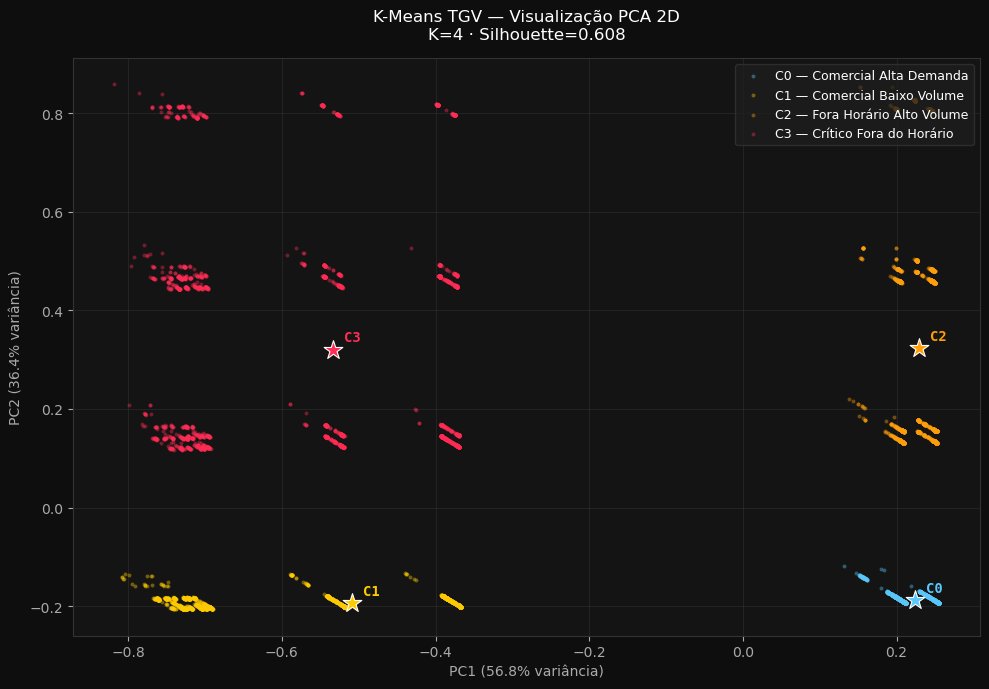

✅ Gráfico PCA salvo


In [12]:
# ── Reduzir para 2D com PCA para visualizar os clusters ───────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

variancia = pca.explained_variance_ratio_
print(f'Variância explicada: PC1={variancia[0]*100:.1f}% | PC2={variancia[1]*100:.1f}% | Total={sum(variancia)*100:.1f}%')

# ── Gráfico scatter PCA ───────────────────────────────────────────────────────
CORES = ['#5ac8fa', '#ffcc00', '#ff9f0a', '#ff2d55']
LABELS = [
    'C0 — Comercial Alta Demanda',
    'C1 — Comercial Baixo Volume',
    'C2 — Fora Horário Alto Volume',
    'C3 — Crítico Fora do Horário',
]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0e0e0e')
ax.set_facecolor('#141414')

for c in range(4):
    mask = kpi['cluster'] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=CORES[c], label=LABELS[c],
        alpha=0.4, s=8, linewidths=0,
    )

# Plotar centroides
centroides_pca = pca.transform(km.cluster_centers_)
for c in range(4):
    ax.scatter(
        centroides_pca[c, 0], centroides_pca[c, 1],
        c=CORES[c], s=200, marker='*',
        edgecolors='white', linewidths=0.8, zorder=5,
    )
    ax.annotate(
        f'C{c}',
        (centroides_pca[c, 0], centroides_pca[c, 1]),
        textcoords='offset points', xytext=(8, 6),
        fontfamily='monospace', fontsize=10,
        fontweight='bold', color=CORES[c],
    )

ax.set_title('K-Means TGV — Visualização PCA 2D\nK=4 · Silhouette=0.608',
             color='white', fontsize=12, pad=14)
ax.set_xlabel(f'PC1 ({variancia[0]*100:.1f}% variância)', color='#aaaaaa')
ax.set_ylabel(f'PC2 ({variancia[1]*100:.1f}% variância)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.legend(fontsize=9, facecolor='#1e1e1e', edgecolor='#333333',
          labelcolor='white', loc='upper right')
ax.grid(alpha=0.1)
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

plt.tight_layout()
plt.savefig('../outputs/kmeans_pca.png', dpi=150, bbox_inches='tight', facecolor='#0e0e0e')
plt.show()
print('✅ Gráfico PCA salvo')

Variância explicada: PC1=56.8% | PC2=36.4% | Total=93.2%

=== Centroides PCA (posição de cada cluster) ===
  Cluster 0: PC1=0.224 | PC2=-0.188
  Cluster 1: PC1=-0.509 | PC2=-0.194
  Cluster 2: PC1=0.229 | PC2=0.323
  Cluster 3: PC1=-0.533 | PC2=0.320

=== Amostra de pontos PCA por cluster (primeiros 5 de cada) ===
  Cluster 0:
    ponto 0: PC1=0.231 PC2=-0.171
    ponto 1: PC1=0.232 PC2=-0.172
    ponto 2: PC1=0.232 PC2=-0.172
    ponto 3: PC1=0.231 PC2=-0.171
    ponto 4: PC1=0.212 PC2=-0.193
  Cluster 1:
    ponto 0: PC1=-0.540 PC2=-0.181
    ponto 1: PC1=-0.368 PC2=-0.200
    ponto 2: PC1=-0.539 PC2=-0.181
    ponto 3: PC1=-0.539 PC2=-0.182
    ponto 4: PC1=-0.722 PC2=-0.183
  Cluster 2:
    ponto 0: PC1=0.229 PC2=0.153
    ponto 1: PC1=0.229 PC2=0.153
    ponto 2: PC1=0.229 PC2=0.154
    ponto 3: PC1=0.246 PC2=0.459
    ponto 4: PC1=0.227 PC2=0.477
  Cluster 3:
    ponto 0: PC1=-0.775 PC2=0.511
    ponto 1: PC1=-0.541 PC2=0.143
    ponto 2: PC1=-0.542 PC2=0.144
    ponto 3: PC1=-0.

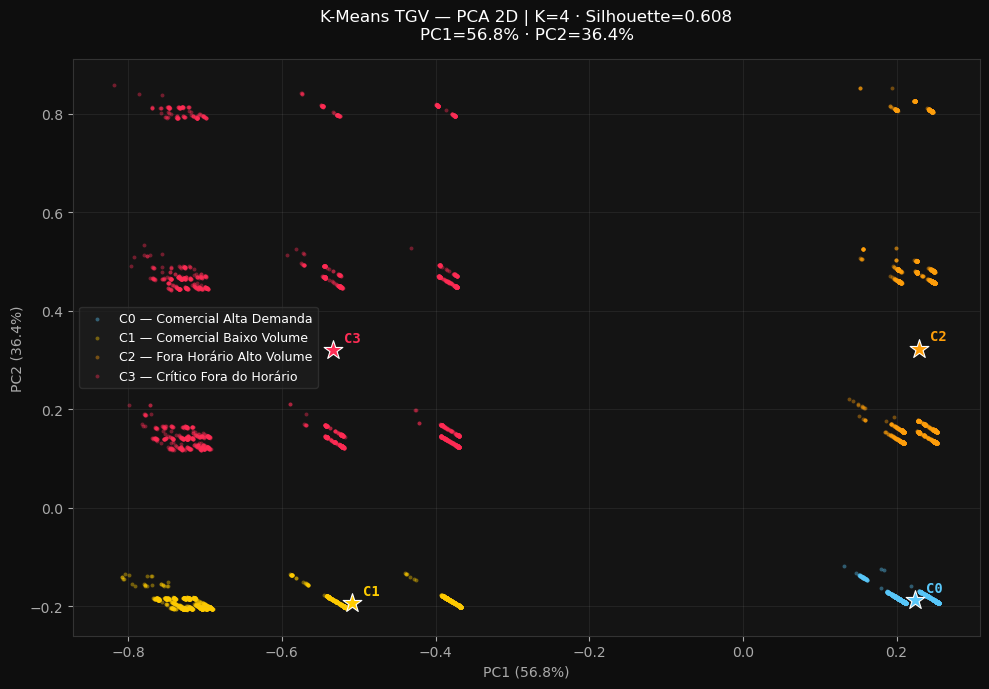

✅ Gráfico PCA salvo em outputs/kmeans_pca.png


In [13]:
# ── Reduzir para 2D com PCA ───────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

variancia = pca.explained_variance_ratio_
print(f'Variância explicada: PC1={variancia[0]*100:.1f}% | PC2={variancia[1]*100:.1f}% | Total={sum(variancia)*100:.1f}%')
print()

# ── Centroides no espaço PCA ──────────────────────────────────────────────────
centroides_pca = pca.transform(km.cluster_centers_)
print('=== Centroides PCA (posição de cada cluster) ===')
for c in range(4):
    print(f'  Cluster {c}: PC1={centroides_pca[c,0]:.3f} | PC2={centroides_pca[c,1]:.3f}')
print()

# ── Amostra de pontos por cluster (100 por cluster) ───────────────────────────
print('=== Amostra de pontos PCA por cluster (primeiros 5 de cada) ===')
for c in range(4):
    mask = kpi['cluster'].values == c
    pts  = X_pca[mask][:5]
    print(f'  Cluster {c}:')
    for i, (x, y) in enumerate(pts):
        print(f'    ponto {i}: PC1={x:.3f} PC2={y:.3f}')
print()

# ── Separação entre clusters ──────────────────────────────────────────────────
print('=== Distância euclidiana entre centroides ===')
for i in range(4):
    for j in range(i+1, 4):
        dist = np.sqrt(((centroides_pca[i] - centroides_pca[j])**2).sum())
        print(f'  C{i} ↔ C{j}: {dist:.3f}')

# Salvar gráfico mesmo assim
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0e0e0e')
ax.set_facecolor('#141414')
CORES  = ['#5ac8fa', '#ffcc00', '#ff9f0a', '#ff2d55']
LABELS = ['C0 — Comercial Alta Demanda', 'C1 — Comercial Baixo Volume',
          'C2 — Fora Horário Alto Volume', 'C3 — Crítico Fora do Horário']
for c in range(4):
    mask = kpi['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=CORES[c],
               label=LABELS[c], alpha=0.4, s=8, linewidths=0)
for c in range(4):
    ax.scatter(centroides_pca[c, 0], centroides_pca[c, 1],
               c=CORES[c], s=200, marker='*', edgecolors='white',
               linewidths=0.8, zorder=5)
    ax.annotate(f'C{c}', (centroides_pca[c, 0], centroides_pca[c, 1]),
                textcoords='offset points', xytext=(8, 6),
                fontfamily='monospace', fontsize=10,
                fontweight='bold', color=CORES[c])
ax.set_title(f'K-Means TGV — PCA 2D | K=4 · Silhouette=0.608\nPC1={variancia[0]*100:.1f}% · PC2={variancia[1]*100:.1f}%',
             color='white', fontsize=12, pad=14)
ax.set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)', color='#aaaaaa')
ax.set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.legend(fontsize=9, facecolor='#1e1e1e', edgecolor='#333333', labelcolor='white')
ax.grid(alpha=0.1)
for spine in ax.spines.values(): spine.set_edgecolor('#333333')
plt.tight_layout()
plt.savefig('../outputs/kmeans_pca.png', dpi=150, bbox_inches='tight', facecolor='#0e0e0e')
plt.show()
print('✅ Gráfico PCA salvo em outputs/kmeans_pca.png')

## ✅ Notebook 05 — Concluído

### Metodologia TGV

Framework RFM adaptado para ITSM — reduz os incidentes a 3 scores interpretáveis:

| Score | Composição | Peso |
|---|---|---|
| **T — Temporalidade** | hora_abertura (0.7) + fim_de_semana (0.3) | Quando ocorre |
| **G — Gravidade** | prioridade (0.4) + violou_OLA (0.4) + duracao_log (0.2) | Quão crítico |
| **V — Volume** | frequência normalizada por grupo | Quanta demanda |

### Seleção de K

K=4 selecionado por interpretabilidade — K=5+ subdivide sem ganho de negócio.

| K | Silhouette | Decisão |
|---|---|---|
| 3 | 0.5992 | Poucos clusters |
| **4** | **0.6084** | **✅ Escolhido** |
| 5 | 0.6180 | Subdivide sem significado |

### Clusters identificados

| Cluster | Nome | Tamanho | Violação | Perfil |
|---|---|---|---|---|
| 0 | Operação Comercial de Alta Demanda | 10.951 | 0.7% | Horário comercial, Team11+Team14, alto volume |
| 1 | Operação Comercial de Baixo Volume | 4.779 | 1.3% | Horário comercial, equipes menores, P2 elevado |
| 2 | Operação Fora do Horário — Alto Volume | 6.463 | 0.6% | Noite+FDS, Team14, alto volume |
| 3 | Operação Crítica Fora do Horário | 2.813 | **2.1%** | Noite+FDS, equipes menores — **maior risco** |

### PCA 2D

Variância explicada: PC1=56.8% · PC2=36.4% · Total=93.2%

Os 4 clusters estão visivelmente separados no espaço 2D — confirmando
que o TGV capturou grupos reais e não artefatos matemáticos.

### Output gerado
- `outputs/clusters.json`
- `outputs/kmeans_elbow.png`
- `outputs/kmeans_pca.png`